In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [13]:
df=pd.read_csv("diabetes.csv")
x=df.drop("Outcome",axis=1)
y=df["Outcome"]

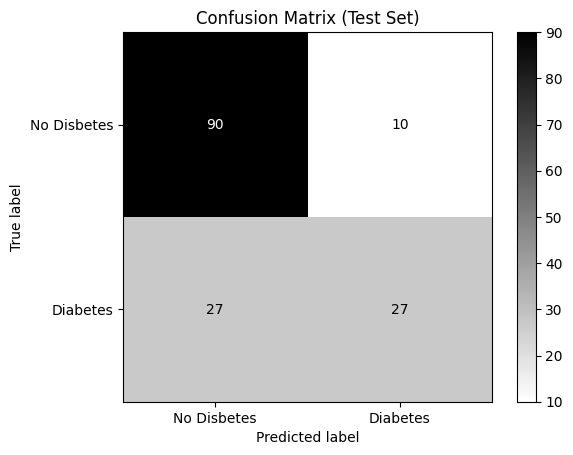

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       100
           1       0.73      0.50      0.59        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.71       154
weighted avg       0.76      0.76      0.75       154



In [31]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101,stratify=y)
scaler=StandardScaler()
X_train["Insulin"]=scaler.fit_transform(X_train[["Insulin"]])
X_test["Insulin"]=scaler.transform(X_test[["Insulin"]])

model=LogisticRegression(max_iter=50)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["No Disbetes","Diabetes"]).plot(cmap="binary")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print(classification_report(y_test, y_pred))